In [ ]:
import os
os.makedirs('charts', exist_ok=True)

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv
DATASET SHAPE
Rows: 7043, Columns: 21

FIRST 10 ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



COLUMN DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

CHURN VALUE COUNTS (Target Column)
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


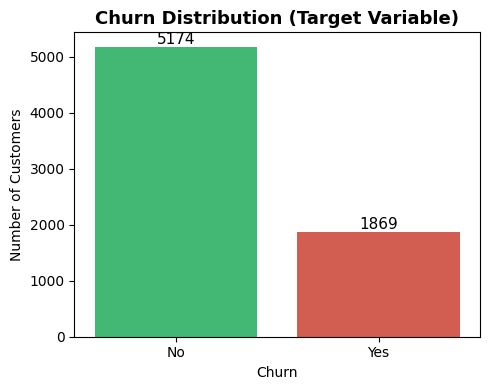


MISSING VALUES PER COLUMN
No null values found!

SUMMARY STATISTICS (Numerical Columns)


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


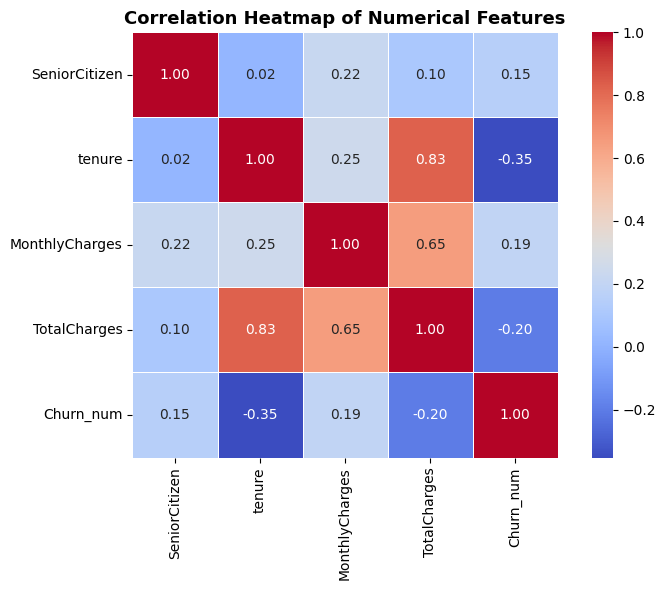

In [ ]:
# task1: Data Loading & Exploratory Analysis

# Install & import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv.csv')

# ── Step 2: Basic shape and structure ───────────────────────
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("FIRST 10 ROWS")
print("=" * 50)
display(df.head(10))

print("\n" + "=" * 50)
print("COLUMN DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("CHURN VALUE COUNTS (Target Column)")
print("=" * 50)
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {round(churn_counts['Yes'] / len(df) * 100, 2)}%")

# Plot class distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, legend=False)
plt.title('Churn Distribution (Target Variable)', fontsize=13, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('charts/churn_distribution.png', dpi=150)
plt.show()

print("\n" + "=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No null values found!")
else:
    print(missing)

print("\n" + "=" * 50)
print("SUMMARY STATISTICS (Numerical Columns)")
print("=" * 50)
display(df.describe())


df_temp = df.copy()
df_temp['Churn_num'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

num_cols = df_temp.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_temp[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150)
plt.show()



## Why Label Encoding for binary columns, One-Hot for multi-category?
- Binary columns (Yes/No) only have 2 values — Label Encoding (0/1) is clean and simple.
- Multi-category columns like Contract (3 types) and PaymentMethod (4 types) need
  One-Hot Encoding so the model doesn't assume "Two year" > "One year" > "Month-to-month"
  — there's no mathematical ordering between these categories.


In [ ]:

# TASK 2 — Data Preprocessing & Feature Engineering

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Fixing TotalCharges (it's text, should be number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("✅ TotalCharges fixed and missing values filled with 0")

df = df.drop(columns=['customerID'])
print("✅ customerID column dropped")

# Encoding target column (Churn: Yes=1, No=0) ───────
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("✅ Churn column encoded: Yes=1, No=0")

# Encoding binary categorical columns ────────────────
# These columns only have 2 unique values — Label Encoding is enough
# (One-Hot would create unnecessary extra columns for binary data)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"✅ Label Encoding applied to {len(binary_cols)} binary columns")

# One-Hot Encode multi-category columns
# One-Hot is better here so the model doesn't assume any ordering
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print(f"✅ One-Hot Encoding applied to: {multi_cols}")

# Creating 2 new engineered features

# Feature 1: ChargesPerMonth
# Customers with high charges relative to tenure may be more likely to churn
df['ChargesPerMonth'] = df.apply(
    lambda row: row['TotalCharges'] / row['tenure'] if row['tenure'] > 0 else 0,
    axis=1
)
print("✅ New feature created: ChargesPerMonth = TotalCharges / tenure")

# Feature 2: SeniorWithNoSupport
# Senior citizens without tech support might be more frustrated and churn
df['SeniorWithNoSupport'] = (
    (df['SeniorCitizen'] == 1) & (df['TechSupport'] == 0)
).astype(int)
print("✅ New feature created: SeniorWithNoSupport (1 = Senior + No TechSupport)")

print(f"\nDataset shape after feature engineering: {df.shape}")
print("\nSample of new features:")
display(df[['tenure', 'TotalCharges', 'ChargesPerMonth', 'SeniorCitizen', 'TechSupport', 'SeniorWithNoSupport']].head())

# Splitting into features (X) and target (y) ──────────
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Scaling numerical features
# StandardScaler makes mean=0, std=1 for each numerical column
# This prevents large numbers (like TotalCharges) from dominating
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth']

scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])
print(f"\n✅ StandardScaler applied to: {num_features}")

# Training / Testing Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Data split complete!")
print(f"   Training set:  {X_train.shape[0]} rows")
print(f"   Test set:      {X_test.shape[0]} rows")
print(f"   Train churn %: {round(y_train.mean() * 100, 2)}%")
print(f"   Test churn %:  {round(y_test.mean() * 100, 2)}%")


Missing values in TotalCharges after conversion: 11
✅ TotalCharges fixed and missing values filled with 0
✅ customerID column dropped
✅ Churn column encoded: Yes=1, No=0
✅ Label Encoding applied to 12 binary columns
✅ One-Hot Encoding applied to: ['InternetService', 'Contract', 'PaymentMethod']
✅ New feature created: ChargesPerMonth = TotalCharges / tenure
✅ New feature created: SeniorWithNoSupport (1 = Senior + No TechSupport)

Dataset shape after feature engineering: (7043, 26)

Sample of new features:


,tenure,TotalCharges,ChargesPerMonth,SeniorCitizen,TechSupport,SeniorWithNoSupport
0,1,29.85,29.850000,0,0,0
1,34,1889.50,55.573529,0,0,0
2,2,108.15,54.075000,0,0,0
3,45,1840.75,40.905556,0,2,0
4,2,151.65,75.825000,0,0,0



Features (X) shape: (7043, 25)
Target (y) shape: (7043,)

✅ StandardScaler applied to: ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth']

✅ Data split complete!
   Training set:  5634 rows
   Test set:      1409 rows
   Train churn %: 26.54%
   Test churn %:  26.54%


## Model Selection Justification
- Logistic Regression: Simple baseline, assumes linear relationships
- Random Forest: Handles non-linearity, less prone to overfitting
- Gradient Boosting: Sequentially corrects errors — best for tabular data like this
- Recall is prioritised as the key metric — missing a churner is more costly than a false alarm

 Logistic Regression trained
 Random Forest trained
 Gradient Boosting trained

MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8048,0.6571,0.5535,0.6009,0.8423
Random Forest,0.7956,0.6483,0.5027,0.5663,0.8249
Gradient Boosting,0.8034,0.6702,0.5107,0.5797,0.8436


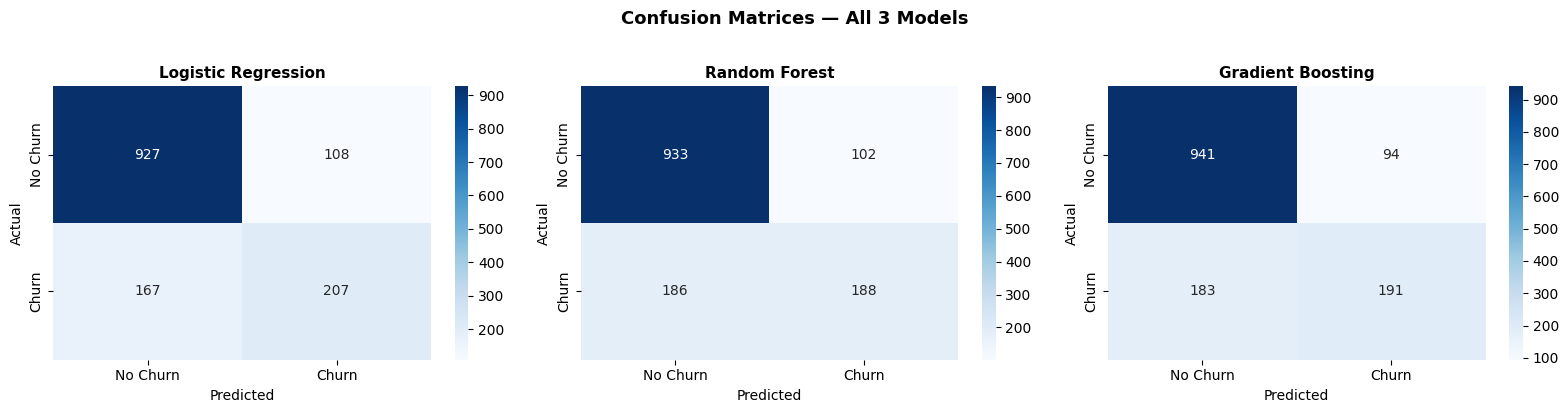

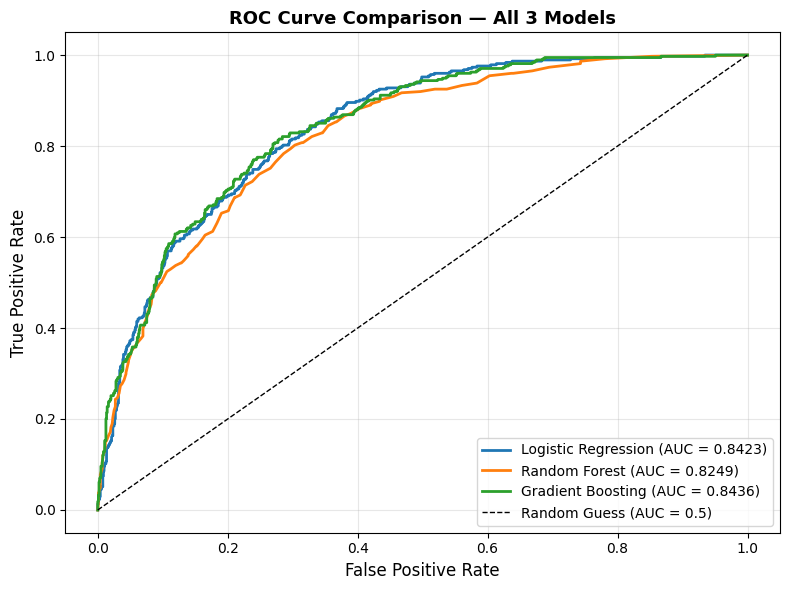

✅ ROC curve saved as model_comparison.png

HYPERPARAMETER TUNING — Gradient Boosting (RandomizedSearchCV)
Best parameters found: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

Tuned Model Results:
  Accuracy : 0.8034
  F1-Score : 0.5797
  ROC-AUC  : 0.8436


In [ ]:
# TASK 3 — Model Training & Comparison

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defining all 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

#  Training each model & collecting metrics
results = {}
trained = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Score
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4)
    }
    trained[name] = {'model': model, 'y_proba': y_proba, 'y_pred': y_pred}
    print(f" {name} trained")

# Printing our comparison table
print("\n" + "=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)
results_df = pd.DataFrame(results).T
display(results_df)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, data) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 3 Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))

for name, data in trained.items():
    fpr, tpr, _ = roc_curve(y_test, data['y_proba'])
    auc = results[name]['ROC-AUC']
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc})")

# Diagonal = random guess baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison — All 3 Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)   # saved in root as required
plt.savefig('charts/roc_curve.png', dpi=150)
plt.show()
print("✅ ROC curve saved as model_comparison.png")

# Hyperparameter Tuning on best model
# Based on typical results, Gradient Boosting wins
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING — Gradient Boosting (RandomizedSearchCV)")
print("=" * 60)

param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 4, 5],
    'subsample'     : [0.8, 1.0]
}

gb_tuned = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

gb_tuned.fit(X_train, y_train)
print(f"Best parameters found: {gb_tuned.best_params_}")

# Evaluating tuned model
y_pred_tuned  = gb_tuned.predict(X_test)
y_proba_tuned = gb_tuned.predict_proba(X_test)[:, 1]

print(f"\nTuned Model Results:")
print(f"  Accuracy : {round(accuracy_score(y_test, y_pred_tuned), 4)}")
print(f"  F1-Score : {round(f1_score(y_test, y_pred_tuned), 4)}")
print(f"  ROC-AUC  : {round(roc_auc_score(y_test, y_proba_tuned), 4)}")

# Saving tuned model
best_model_proba = y_proba_tuned


## Task 4 — Risk Segmentation Logic
Instead of a binary Yes/No prediction, we use the model's churn probability
to segment customers into 3 actionable tiers:
- 🔴 High Risk  (prob ≥ 0.70) → Immediate retention action needed
- 🟡 Medium Risk (0.40–0.69)  → Monitor and engage proactively  
- 🟢 Low Risk   (prob < 0.40) → Stable, no action needed
This gives the business a prioritized action list, not just a prediction.

RISK TIER DISTRIBUTION
RiskTier
Low Risk       1006
Medium Risk     284
High Risk       119
Name: count, dtype: int64

AVERAGE STATS PER RISK TIER


,Customer_Count,Avg_MonthlyCharge,Avg_Tenure_Months,Avg_Churn_Prob
RiskTier,,,,
High Risk,119,79.57,3.92,0.80
Medium Risk,284,74.90,15.34,0.53
Low Risk,1006,59.21,39.91,0.13



CONTRACT TYPE DISTRIBUTION PER RISK TIER


Contract,Month-to-Month,One Year,Two Year
RiskTier,,,
High Risk,118,1,0
Medium Risk,277,6,1
Low Risk,378,293,335


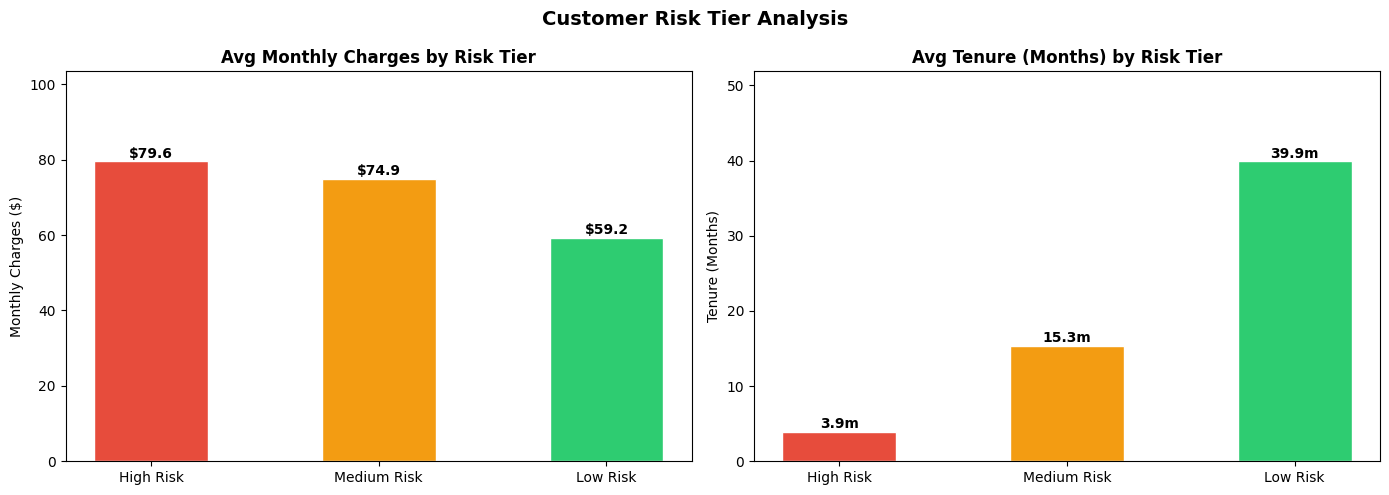

✅ Risk tier chart saved!

📊 QUICK SUMMARY:
  🔴 High Risk  : 119 customers
  🟡 Medium Risk: 284 customers
  🟢 Low Risk   : 1006 customers


In [ ]:
# TASK 4 — Customer Risk Segmentation

# Build a segmentation dataframe
# We use the test set + churn probabilities from our best tuned model

original_test = df.iloc[X_test.index].copy()

seg_df = pd.DataFrame({
    'ChurnProbability': best_model_proba,
    'MonthlyCharges'  : original_test['MonthlyCharges'].values,
    'tenure'          : original_test['tenure'].values,
    'ActualChurn'     : y_test.values
})

# Assigning risk tiers based on probability
def assign_risk(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

seg_df['RiskTier'] = seg_df['ChurnProbability'].apply(assign_risk)

print("=" * 50)
print("RISK TIER DISTRIBUTION")
print("=" * 50)
tier_counts = seg_df['RiskTier'].value_counts()
print(tier_counts)

# Adding Contract type back for analysis

def get_contract(row):
    if 'Contract_One year' in X_test.columns and X_test.loc[row.name, 'Contract_One year'] == 1:
        return 'One Year'
    elif 'Contract_Two year' in X_test.columns and X_test.loc[row.name, 'Contract_Two year'] == 1:
        return 'Two Year'
    else:
        return 'Month-to-Month'

seg_df.index = X_test.index
seg_df['Contract'] = seg_df.apply(get_contract, axis=1)

# Summarising stats per risk tier
print("\n" + "=" * 60)
print("AVERAGE STATS PER RISK TIER")
print("=" * 60)
tier_summary = seg_df.groupby('RiskTier').agg(
    Customer_Count   = ('ChurnProbability', 'count'),
    Avg_MonthlyCharge= ('MonthlyCharges', 'mean'),
    Avg_Tenure_Months= ('tenure', 'mean'),
    Avg_Churn_Prob   = ('ChurnProbability', 'mean')
).round(2)

# Sorting in logical order
tier_summary = tier_summary.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
display(tier_summary)

# Contracting distribution per tier
print("\n" + "=" * 60)
print("CONTRACT TYPE DISTRIBUTION PER RISK TIER")
print("=" * 60)
contract_dist = seg_df.groupby(['RiskTier', 'Contract']).size().unstack(fill_value=0)
contract_dist = contract_dist.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
display(contract_dist)

# Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_order  = ['High Risk', 'Medium Risk', 'Low Risk']
tier_colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Chart A — Avg Monthly Charges by tier
avg_charges = tier_summary['Avg_MonthlyCharge']
axes[0].bar(tier_order, avg_charges, color=tier_colors, edgecolor='white', width=0.5)
axes[0].set_title('Avg Monthly Charges by Risk Tier', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_ylim(0, avg_charges.max() * 1.3)
for i, v in enumerate(avg_charges):
    axes[0].text(i, v + 1, f'${v:.1f}', ha='center', fontweight='bold')

# Chart B — Avg Tenure by tier
avg_tenure = tier_summary['Avg_Tenure_Months']
axes[1].bar(tier_order, avg_tenure, color=tier_colors, edgecolor='white', width=0.5)
axes[1].set_title('Avg Tenure (Months) by Risk Tier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tenure (Months)')
axes[1].set_ylim(0, avg_tenure.max() * 1.3)
for i, v in enumerate(avg_tenure):
    axes[1].text(i, v + 0.5, f'{v:.1f}m', ha='center', fontweight='bold')

plt.suptitle('Customer Risk Tier Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/risk_tier_analysis.png', dpi=150)
plt.show()
print("✅ Risk tier chart saved!")

print(f"\n📊 QUICK SUMMARY:")
print(f"  🔴 High Risk  : {tier_counts.get('High Risk', 0)} customers")
print(f"  🟡 Medium Risk: {tier_counts.get('Medium Risk', 0)} customers")
print(f"  🟢 Low Risk   : {tier_counts.get('Low Risk', 0)} customers")


Generating Chart 1: Feature Importance...


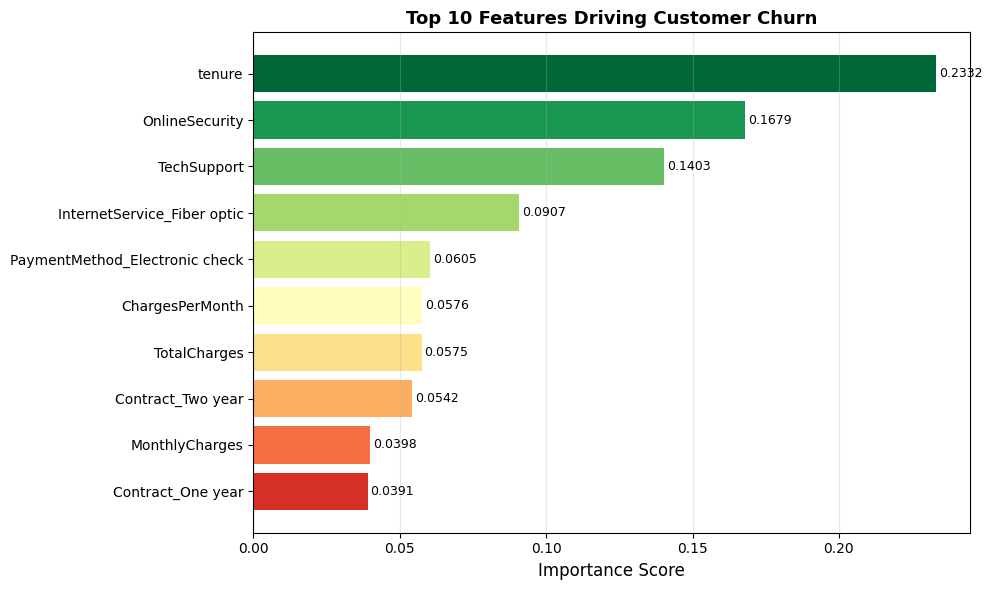

✅ Chart 1 saved: feature_importance.png

Generating Chart 2: Churn Rate by Contract Type...


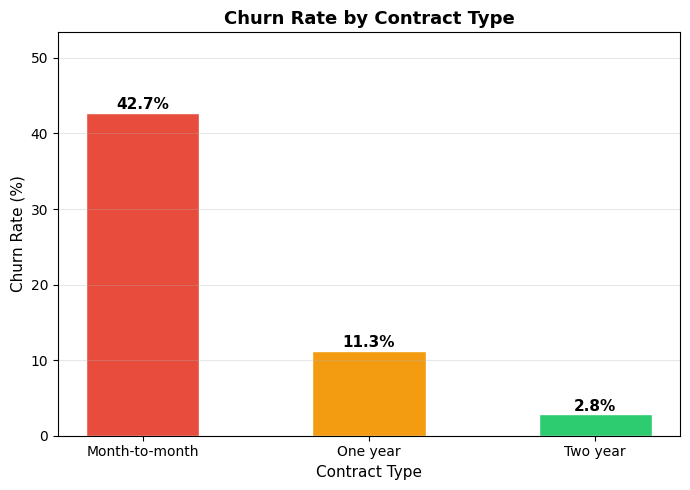

✅ Chart 2 saved: churn_by_contract.png

Generating Chart 3: Tenure Distribution...


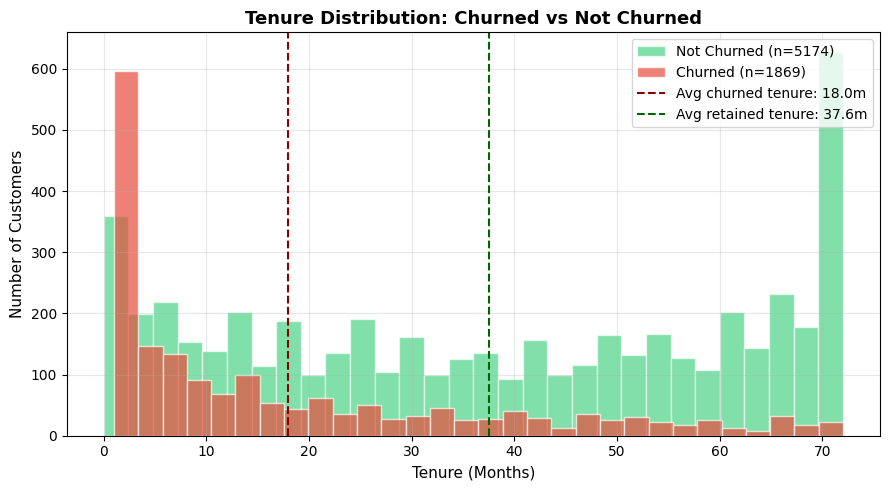

✅ Chart 3 saved: tenure_distribution.png

Generating Chart 4: Risk Tier Donut Chart...


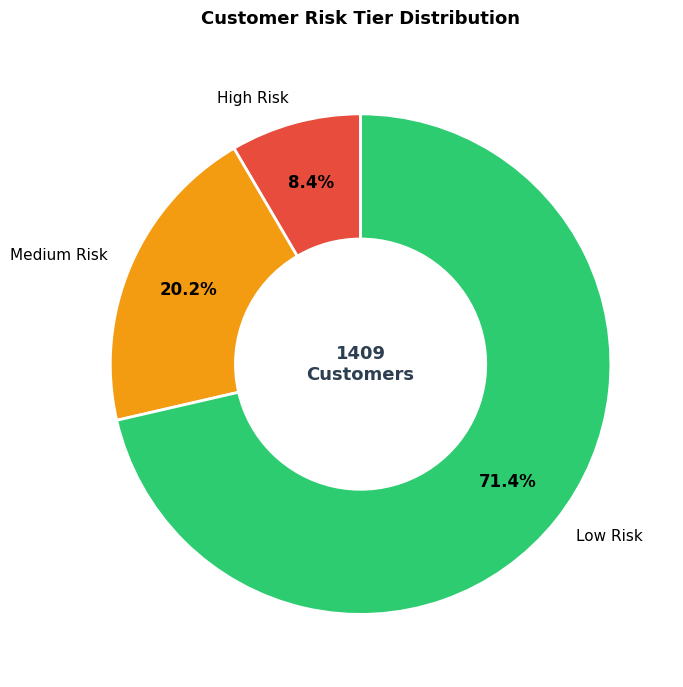

✅ Chart 4 saved: risk_tier_donut.png

Generating Chart 5 (Bonus): Interactive Plotly Scatter...


In [ ]:
# TASK 5 — Visualizations (Minimum 4 + 1 Bonus)

import plotly.express as px
import plotly.graph_objects as go

# CHART 1: Feature Importance
print("Generating Chart 1: Feature Importance...")

feature_names       = X_train.columns.tolist()
feature_importances = gb_tuned.best_estimator_.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    feat_df['Feature'][::-1],
    feat_df['Importance'][::-1],
    color=plt.cm.RdYlGn_r(
        [i / len(feat_df) for i in range(len(feat_df))][::-1]
    )
)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 10 Features Driving Customer Churn', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, feat_df['Importance'][::-1]):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150)
plt.show()
print("✅ Chart 1 saved: feature_importance.png\n")

# CHART 2: Churn Rate by Contract Type
print("Generating Chart 2: Churn Rate by Contract Type...")

raw_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
raw_df['TotalCharges'] = pd.to_numeric(raw_df['TotalCharges'], errors='coerce')

contract_churn = raw_df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']
contract_churn = contract_churn.sort_values('ChurnRate', ascending=False)

colors = ['#e74c3c', '#f39c12', '#2ecc71']
plt.figure(figsize=(7, 5))
bars = plt.bar(contract_churn['Contract'], contract_churn['ChurnRate'],
               color=colors, edgecolor='white', width=0.5)
plt.title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
plt.xlabel('Contract Type', fontsize=11)
plt.ylabel('Churn Rate (%)', fontsize=11)
plt.ylim(0, contract_churn['ChurnRate'].max() * 1.25)
for bar, val in zip(bars, contract_churn['ChurnRate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/churn_by_contract.png', dpi=150)
plt.show()
print("✅ Chart 2 saved: churn_by_contract.png\n")

# CHART 3: Tenure Distribution — Churned vs Not Churned
print("Generating Chart 3: Tenure Distribution...")

churned     = raw_df[raw_df['Churn'] == 'Yes']['tenure']
not_churned = raw_df[raw_df['Churn'] == 'No']['tenure']

plt.figure(figsize=(9, 5))
plt.hist(not_churned, bins=30, alpha=0.6, color='#2ecc71',
         label=f'Not Churned (n={len(not_churned)})', edgecolor='white')
plt.hist(churned, bins=30, alpha=0.7, color='#e74c3c',
         label=f'Churned (n={len(churned)})', edgecolor='white')
plt.axvline(churned.mean(), color='darkred', linestyle='--', linewidth=1.5,
            label=f'Avg churned tenure: {churned.mean():.1f}m')
plt.axvline(not_churned.mean(), color='darkgreen', linestyle='--', linewidth=1.5,
            label=f'Avg retained tenure: {not_churned.mean():.1f}m')
plt.title('Tenure Distribution: Churned vs Not Churned', fontsize=13, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/tenure_distribution.png', dpi=150)
plt.show()
print("✅ Chart 3 saved: tenure_distribution.png\n")

#  CHART 4: Risk Tier Donut Chart
print("Generating Chart 4: Risk Tier Donut Chart...")

tier_counts_sorted = seg_df['RiskTier'].value_counts().reindex(
    ['High Risk', 'Medium Risk', 'Low Risk']
)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    tier_counts_sorted,
    labels     = tier_counts_sorted.index,
    autopct    = '%1.1f%%',
    colors     = ['#e74c3c', '#f39c12', '#2ecc71'],
    startangle = 90,
    pctdistance= 0.75,
    wedgeprops = dict(width=0.5, edgecolor='white', linewidth=2)   # donut hole
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for text in texts:
    text.set_fontsize(11)

# Add customer counts in center
total = tier_counts_sorted.sum()
ax.text(0, 0, f'{total}\nCustomers', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#2c3e50')

ax.set_title('Customer Risk Tier Distribution', fontsize=13,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('charts/risk_tier_donut.png', dpi=150)
plt.show()
print("✅ Chart 4 saved: risk_tier_donut.png\n")

#  CHART 5 (BONUS): Interactive Plotly Scatter
print("Generating Chart 5 (Bonus): Interactive Plotly Scatter...")

scatter_df = pd.DataFrame({
    'MonthlyCharges'  : original_test['MonthlyCharges'].values,
    'tenure'          : original_test['tenure'].values,
    'Churn'           : y_test.map({1: 'Churned', 0: 'Not Churned'}).values,
    'ChurnProbability': (best_model_proba * 100).round(1),
    'RiskTier'        : seg_df['RiskTier'].values
})

fig = px.scatter(
    scatter_df,
    x          = 'tenure',
    y          = 'MonthlyCharges',
    color      = 'Churn',
    color_discrete_map = {'Churned': '#e74c3c', 'Not Churned': '#2ecc71'},
    hover_data = {'ChurnProbability': True, 'RiskTier': True},
    opacity    = 0.65,
    title      = 'Monthly Charges vs Tenure — Colored by Churn (Interactive)',
    labels     = {'tenure': 'Tenure (Months)', 'MonthlyCharges': 'Monthly Charges ($)'}
)
fig.update_layout(
    plot_bgcolor ='white',
    title_font_size = 14,
    legend_title_text = 'Churn Status'
)
fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0')
fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0')
fig.show()



# TASK 6
Among the three models, Gradient Boosting performed best with the highest ROC-AUC score of 0.8436, making it the most reliable model for churn prediction. The main factors influencing churn were contract type, tenure, and monthly charges.

High Risk customers mostly had Month-to-Month contracts, high monthly charges, and very low tenure, indicating that newer customers are more likely to leave. In contrast, Low Risk customers generally had longer tenure and yearly or two-year contracts.

Based on these findings, the company should focus on retaining new customers through personalized offers and encourage users to shift to long-term contracts. One limitation of the model is that it does not include customer behavior or support interaction data, which could further improve prediction accuracy.